# Persona 2 – Demanda y Evaluación

## Objetivo
Implementar la función que calcula el **costo promedio ponderado** de una configuración de estaciones de tren, recibiendo como entrada las matrices de población generadas por la Persona 1 y entregando como salida la métrica que la Persona 3 minimizará.

---

## Modelo de Demanda

### Notación
- Cuadrícula $R \times C$ (filas $\times$ columnas).
- $\text{pop}(o)$: población del nodo $o = (r, c)$ en un escenario dado.
- $S = \{s_1, \dots, s_N\}$: conjunto de estaciones de tren.
- $d_{\min}(x, S) = \min_{s \in S} \|x - s\|_1$: distancia Manhattan al nodo $x$ desde la estación más cercana.

### Probabilidades Origen–Destino
Un usuario elige su **origen** $o$ con probabilidad proporcional a la población:
$$P(\text{origen} = o) = \frac{\text{pop}(o)}{\text{pop}_{\text{total}}}$$

Dado el origen $o$, elige su **destino** $d \neq o$ con probabilidad proporcional a la población del destino:
$$P(\text{destino} = d \mid o) = \frac{\text{pop}(d)}{\text{pop}_{\text{total}} - \text{pop}(o)}$$

### Costo de un Viaje
El costo de ir de $o$ a $d$ es la suma de distancias peatonales a la estación más cercana:
$$\text{costo}(o, d) = d_{\min}(o, S) + d_{\min}(d, S)$$
(el trayecto en tren entre estaciones es despreciable)

### Costo Promedio – Derivación
$$E[\text{costo}] = \sum_o P(o) \left[ d_{\min}(o) + \sum_{d \neq o} P(d|o)\, d_{\min}(d) \right]$$

El término interior se simplifica:
$$E[d_{\min}(d) \mid o] = \sum_{d \neq o} \frac{\text{pop}(d)}{\text{pop}_{\text{total}} - \text{pop}(o)}\, d_{\min}(d)
= \frac{\sum_d \text{pop}(d)\, d_{\min}(d) - \text{pop}(o)\, d_{\min}(o)}{\text{pop}_{\text{total}} - \text{pop}(o)}$$

Por lo que el costo total es:
$$\boxed{E[\text{costo}] = \sum_o \frac{\text{pop}(o)}{\text{pop}_{\text{total}}} \left[ d_{\min}(o) + \frac{\sum_d \text{pop}(d)\, d_{\min}(d) - \text{pop}(o)\, d_{\min}(o)}{\text{pop}_{\text{total}} - \text{pop}(o)} \right]}$$

Este cálculo es **O(R·C)** en cada escenario (no requiere enumerar todos los pares OD).

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..'))   # permite importar desde la raíz

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from config import R, C, N_ESTACIONES, T, NUM_ESCENARIOS, SEMILLA
from src.p1_ciudad import generar_escenarios
from src.p2_demanda import distancias_minimas, calcular_costo_escenario, calcular_costo_promedio, costo_por_nodo

np.random.seed(SEMILLA)
print(f'Cuadrícula: {R}×{C}  |  Estaciones máximas: {N_ESTACIONES}  |  Horizonte: {T} años  |  Escenarios: {NUM_ESCENARIOS}')

Cuadrícula: 20×20  |  Estaciones máximas: 6  |  Horizonte: 20 años  |  Escenarios: 30


## 1. Generación de Escenarios (Persona 1)
Se generan los escenarios de población que servirán de entrada.

Escenarios generados: 30
Shape de cada escenario: (20, 20)  (C × R = 20 × 20)
Población total (escenario 0): 31,577


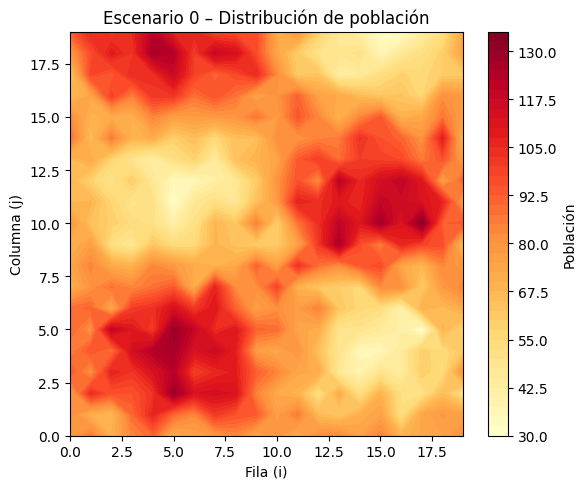

In [2]:
escenarios = generar_escenarios(T, NUM_ESCENARIOS)
print(f'Escenarios generados: {len(escenarios)}')
print(f'Shape de cada escenario: {escenarios[0].shape}  (C × R = {C} × {R})')
print(f'Población total (escenario 0): {escenarios[0].sum():,}')

# Visualizar el primer escenario
ii, jj = np.meshgrid(np.arange(R), np.arange(C))
fig, ax = plt.subplots(figsize=(6, 5))
cf = ax.contourf(ii, jj, escenarios[0], 50, cmap='YlOrRd')
plt.colorbar(cf, ax=ax, label='Población')
ax.set_xlabel('Fila (i)'); ax.set_ylabel('Columna (j)')
ax.set_title('Escenario 0 – Distribución de población')
plt.tight_layout(); plt.show()

## 2. Campo de Distancias a Estaciones
Para una configuración dada, `distancias_minimas()` devuelve la distancia Manhattan de cada nodo a la estación más cercana.

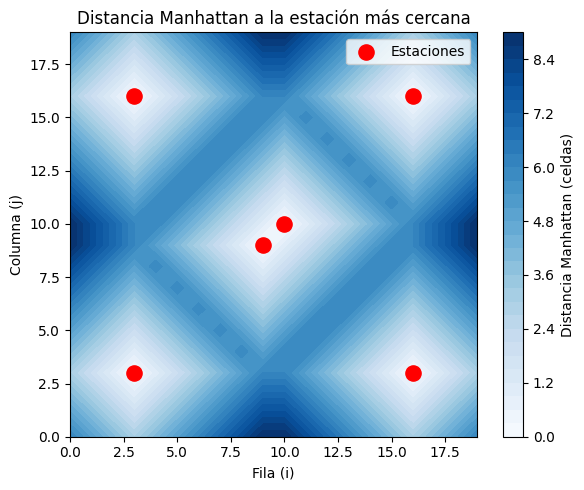

Distancia máxima en la cuadrícula: 9.0 celdas
Distancia promedio simple:          4.38 celdas


In [3]:
# Ejemplo: 6 estaciones distribuidas uniformemente
estaciones_ejemplo = np.array([
    [ 3,  3],
    [ 3, 16],
    [ 9,  9],
    [10, 10],
    [16,  3],
    [16, 16],
])

d_min = distancias_minimas(estaciones_ejemplo)

fig, ax = plt.subplots(figsize=(6, 5))
cf = ax.contourf(ii, jj, d_min, 30, cmap='Blues')
plt.colorbar(cf, ax=ax, label='Distancia Manhattan (celdas)')
ax.scatter(estaciones_ejemplo[:, 0], estaciones_ejemplo[:, 1],
           c='red', s=120, zorder=5, label='Estaciones')
ax.set_xlabel('Fila (i)'); ax.set_ylabel('Columna (j)')
ax.set_title('Distancia Manhattan a la estación más cercana')
ax.legend(); plt.tight_layout(); plt.show()

print(f'Distancia máxima en la cuadrícula: {d_min.max():.1f} celdas')
print(f'Distancia promedio simple:          {d_min.mean():.2f} celdas')

## 3. Costo de un Escenario
Se calcula el costo promedio ponderado por población para el primer escenario.

Costo promedio (escenario 0): 8.8151 celdas


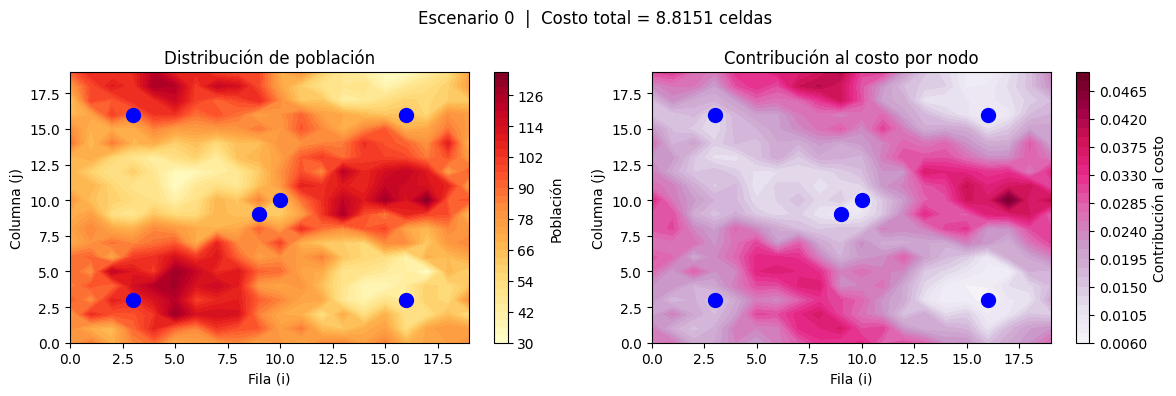

In [4]:
costo_0 = calcular_costo_escenario(escenarios[0], estaciones_ejemplo)
print(f'Costo promedio (escenario 0): {costo_0:.4f} celdas')

# Mapa de contribución al costo por nodo
contrib = costo_por_nodo(escenarios[0], estaciones_ejemplo)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cf0 = axes[0].contourf(ii, jj, escenarios[0], 40, cmap='YlOrRd')
plt.colorbar(cf0, ax=axes[0], label='Población')
axes[0].scatter(estaciones_ejemplo[:, 0], estaciones_ejemplo[:, 1],
                c='blue', s=100, zorder=5)
axes[0].set_title('Distribución de población')

cf1 = axes[1].contourf(ii, jj, contrib, 40, cmap='PuRd')
plt.colorbar(cf1, ax=axes[1], label='Contribución al costo')
axes[1].scatter(estaciones_ejemplo[:, 0], estaciones_ejemplo[:, 1],
                c='blue', s=100, zorder=5)
axes[1].set_title('Contribución al costo por nodo')

for ax in axes:
    ax.set_xlabel('Fila (i)'); ax.set_ylabel('Columna (j)')

plt.suptitle(f'Escenario 0  |  Costo total = {costo_0:.4f} celdas')
plt.tight_layout(); plt.show()

## 4. Costo Promedio sobre Todos los Escenarios
Esta es la **función objetivo** que la Persona 3 minimizará.

Costo promedio sobre 30 escenarios: 8.8399 celdas


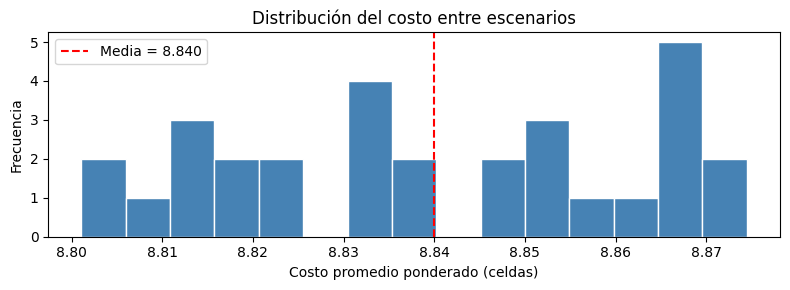

In [5]:
costo_promedio = calcular_costo_promedio(escenarios, estaciones_ejemplo)
print(f'Costo promedio sobre {NUM_ESCENARIOS} escenarios: {costo_promedio:.4f} celdas')

# Distribución del costo por escenario
costos_por_escenario = [calcular_costo_escenario(pob, estaciones_ejemplo) for pob in escenarios]

plt.figure(figsize=(8, 3))
plt.hist(costos_por_escenario, bins=15, color='steelblue', edgecolor='white')
plt.axvline(costo_promedio, color='red', linestyle='--', label=f'Media = {costo_promedio:.3f}')
plt.xlabel('Costo promedio ponderado (celdas)')
plt.ylabel('Frecuencia')
plt.title('Distribución del costo entre escenarios')
plt.legend(); plt.tight_layout(); plt.show()

## 5. Comparación de Configuraciones
Ilustración de cómo la función de costo diferencia configuraciones buenas de malas.

Distribuidas (ejemplo)   : costo = 8.8399 celdas
Centro agrupadas         : costo = 16.1999 celdas
Borde                    : costo = 13.5481 celdas
Diagonal                 : costo = 13.4390 celdas


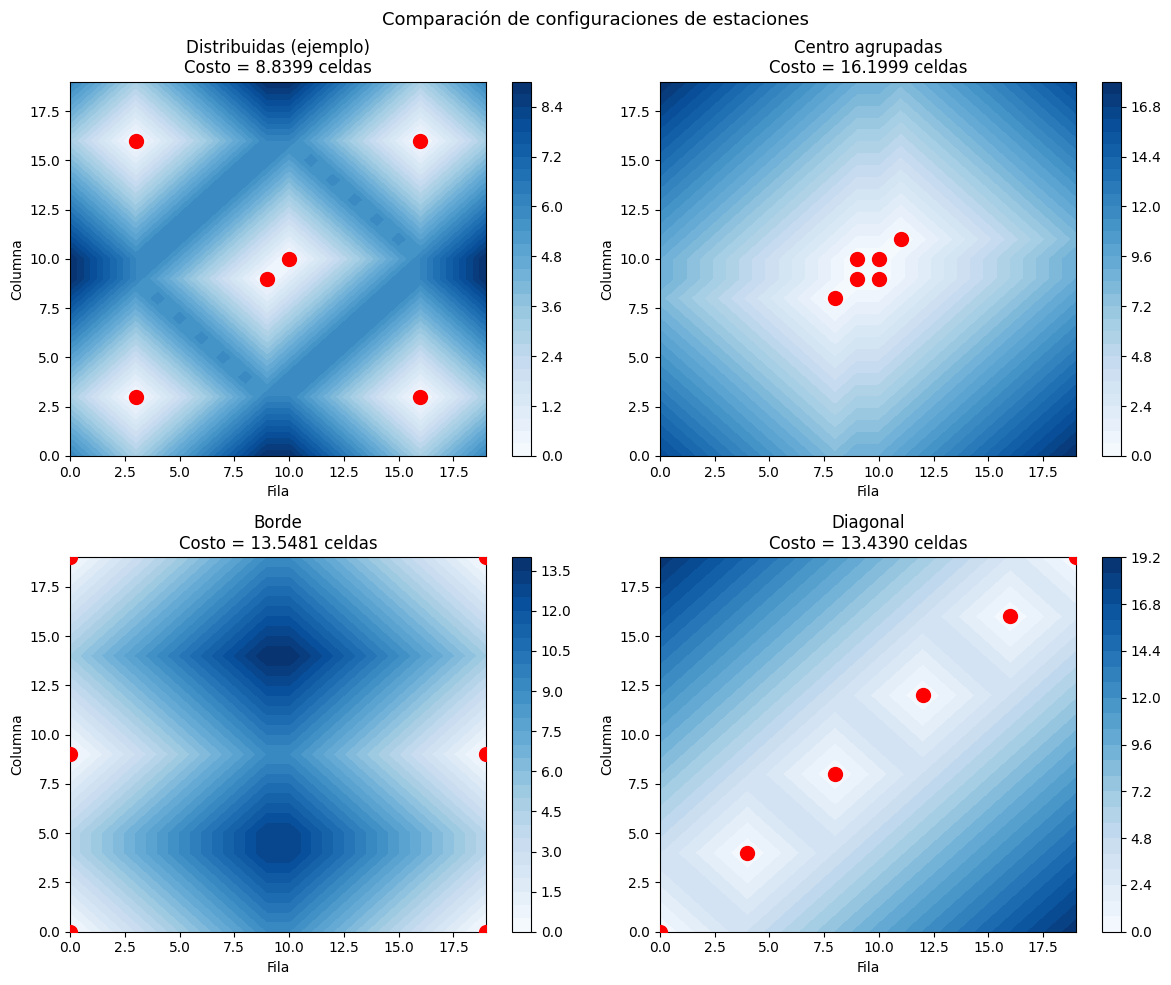

In [6]:
configs = {
    'Distribuidas (ejemplo)': estaciones_ejemplo,
    'Centro agrupadas': np.array([[8,8],[9,9],[10,10],[11,11],[9,10],[10,9]]),
    'Borde': np.array([[0,0],[0,19],[19,0],[19,19],[0,9],[19,9]]),
    'Diagonal': np.array([[0,0],[4,4],[8,8],[12,12],[16,16],[19,19]]),
}

resultados = {}
for nombre, ests in configs.items():
    costo = calcular_costo_promedio(escenarios, ests)
    resultados[nombre] = costo
    print(f'{nombre:25s}: costo = {costo:.4f} celdas')

# Gráfico comparativo de los campos de distancia
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (nombre, ests) in zip(axes, configs.items()):
    d = distancias_minimas(ests)
    cf = ax.contourf(ii, jj, d, 30, cmap='Blues')
    plt.colorbar(cf, ax=ax)
    ax.scatter(ests[:, 0], ests[:, 1], c='red', s=100, zorder=5)
    ax.set_title(f'{nombre}\nCosto = {resultados[nombre]:.4f} celdas')
    ax.set_xlabel('Fila'); ax.set_ylabel('Columna')

plt.suptitle('Comparación de configuraciones de estaciones', fontsize=13)
plt.tight_layout(); plt.show()

## 6. Interfaz para la Persona 3

La función de costo está lista para ser usada por la Persona 3. La interfaz es:

```python
from src.p2_demanda import calcular_costo_promedio

# escenarios: salida de p1.generar_escenarios()  →  list de ndarray (C, R)
# estaciones: array de shape (N, 2), cada fila es (fila, col)

costo = calcular_costo_promedio(escenarios, estaciones)
# costo: float en unidades de celdas (a minimizar)
```

### Resumen de funciones exportadas

| Función | Descripción | Retorna |
|---|---|---|
| `distancias_minimas(estaciones)` | Mapa de distancias Manhattan por nodo | ndarray (C, R) |
| `calcular_costo_escenario(pob, estaciones)` | Costo ponderado para un escenario | float |
| `calcular_costo_promedio(escenarios, estaciones)` | **Función objetivo** sobre todos los escenarios | float |
| `costo_por_nodo(pob, estaciones)` | Contribución al costo por nodo (visualización) | ndarray (C, R) |

In [7]:
# Demo final: la Persona 3 llama a calcular_costo_promedio como función objetivo
def funcion_objetivo(estaciones_flat):
    """Wrapper para optimizadores que trabajan con vectores 1D."""
    n = len(estaciones_flat) // 2
    ests = np.array(estaciones_flat).reshape(n, 2)
    # Clipear a la cuadrícula
    ests[:, 0] = np.clip(ests[:, 0], 0, R - 1)
    ests[:, 1] = np.clip(ests[:, 1], 0, C - 1)
    return calcular_costo_promedio(escenarios, ests)

# Prueba
x0 = estaciones_ejemplo.flatten()
print(f'Costo con estaciones_ejemplo (via wrapper): {funcion_objetivo(x0):.4f}')
print('\n✓ Función de costo lista para la Persona 3.')

Costo con estaciones_ejemplo (via wrapper): 8.8399

✓ Función de costo lista para la Persona 3.
